In [ ]:
import numpy as np
from itertools import combinations
from scipy import stats
from scipy.optimize import curve_fit
import random as rd
import math
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime


In [ ]:
def bs_call(k,s,vol,r,T):
  d1=(np.log(s/k)+(r+(vol**2)/2)*T)/(vol*np.sqrt(T))
  d2=d1-vol*np.sqrt(T)
  return(s*stats.norm.cdf(d1)-k*np.exp(-r*T)*stats.norm.cdf(d2))

def bs_put(k,s,vol,r,T):
  d1=(np.log(s/k)+(r+(vol**2)/2)*T)/(vol*np.sqrt(T))
  d2=d1-vol*np.sqrt(T)
  return(-s*stats.norm.cdf(-d1)+k*np.exp(-r*T)*stats.norm.cdf(-d2))

In [ ]:
print(bs_call(105,100,0.2,0.03,0.5),bs_put(95,100,0.2,0.03,0.5))

4.178299715513496 2.836724577312957


In [ ]:
def tabuler(s,k,vol,T,r,N):
  table=np.zeros((N,N))
  u=np.exp(vol*(T/N))
  d=1/u
  p=(np.exp(r*T/N)-d)/(u-d)
  for i in range(N):
    for j in range(i+1):
      table[i,j]=s*u**j*d**(i-j)

  payoff=np.zeros((N,N))
  payoff[N-1,:]=np.maximum(0,table[N-1,:]-k)

  price=np.zeros((N-1,N-1))
  for i in range(1,N):
    for j in range(1,i):
      price[N-i,N-j]=np.exp(-r*(T/N))*(p*payoff[N-i+1,N-j]+(1-p)*payoff[N-i+1,N-j+1])
  return(table,price,p)

In [ ]:

def binomial_tree_call_price(s, k, vol, T, r, N):

    dt = T / N

    discount = math.exp(-r * dt)

    u = math.exp(vol * math.sqrt(dt))
    d = 1 / u

    p = (math.exp(r * dt) - d) / (u - d)

    stock_prices = [s * (u ** j) * (d ** (N - j)) for j in range(N + 1)]

    option_values = [max(price - k, 0) for price in stock_prices]

    for i in range(N - 1, -1, -1):
        for j in range(i + 1):
            option_values[j] = discount * (p * option_values[j + 1] + (1 - p) * option_values[j])

    return option_values[0]

In [ ]:
binomial_tree_call_price(100,105,0.2,0.5,0.03,1000)

4.179559642690352

In [ ]:
def monte_carlo_call_price(s, k, vol, T, r, N):
  z = np.random.standard_normal(N)

  s_T = s * np.exp((r - 0.5 * vol ** 2) * T + vol * np.sqrt(T) * z)
  payoffs = np.maximum(s_T - k, 0)

  call_price = np.exp(-r * T) * np.mean(payoffs)

  return call_price

In [ ]:
monte_carlo_call_price(100,105,0.2,0.5,0.03,10000000)

4.18104105661613

# ASIAN CALL

In [ ]:
s, k, vol, T,T0, r, N=100,105,0.2,0.5,0.3,0.03,10

daysleft=int((T-T0)*365)
daystot=int(T*365)
dt=1/365
prices=np.zeros((N,daystot))
prices[:,0]=100
for i in range(N):
  z = np.random.standard_normal(daystot-1)
  for j in range(1,daystot):
    prices[i,j] = prices[i,j-1] * np.exp((r - 0.5 * vol ** 2) * dt + vol * np.sqrt(dt) * z[j-1])
prices=np.maximum(0,prices-k)

np.exp(-r*T)*np.mean(prices[:,daystot-daysleft:])

4.761666702422291

In [ ]:
def binomial_tree_american_put_price(s, k, vol, T, r, N):

    dt = T / N

    discount = math.exp(-r * dt)

    u = math.exp(vol * math.sqrt(dt))
    d = 1 / u

    p = (math.exp(r * dt) - d) / (u - d)
    stock=np.zeros((N,N))
    stock[0,0]=s
    for i in range(1,N):
      for j in range(i+1):
        stock[i,j]=s*(u**j)*(d**(i-j))

    payoff=np.zeros((N,N))
    payoff[-1,:]=np.maximum(0,k-stock[-1,:])

    for i in range(N-1,0,-1):
      for j in range(i):
        payoff[i-1,j]=max(np.exp(-r*dt)*(p*payoff[i,j+1]+(1-p)*payoff[i,j]),k-stock[i-1,j])

    return payoff[0,0]

In [ ]:
binomial_tree_american_put_price(100,105,0.2,0.5,0.03,1000)

7.8487463384921945

In [ ]:
import yfinance as yf

ticker = "AAPL"
start_date = "2015-01-01"
end_date = "2024-12-31"

data = yf.download(ticker, start=start_date, end=end_date)
data['returns']=np.log(data['Close'] / data['Close'].shift())

data['std']=data['returns'].rolling(window=150).std()

data

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,returns,std
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2015-01-02,24.347174,24.817059,23.906238,24.805924,212818400,NaN,NaN
2015-01-05,23.661276,24.195743,23.474213,24.115573,257142000,-0.028576,NaN
2015-01-06,23.663496,23.924048,23.300503,23.725850,263188400,0.000094,NaN
2015-01-07,23.995312,24.095523,23.761482,23.872829,160423600,0.013925,NaN
2015-01-08,24.917267,24.975168,24.206871,24.324901,237458000,0.037703,NaN
...,...,...,...,...,...,...,...
2024-12-23,255.270004,255.649994,253.449997,254.770004,40858800,0.003060,0.014174
2024-12-24,258.200012,258.209991,255.289993,255.490005,23234700,0.011413,0.014190


In [ ]:
Rt=[]
for i in range(1,len(data)):
  Rt.append(np.log(data.Close.iloc[i].values[0]/data.Close.iloc[i-1].values[0]))

In [ ]:
std=np.std(Rt)*np.sqrt(252)

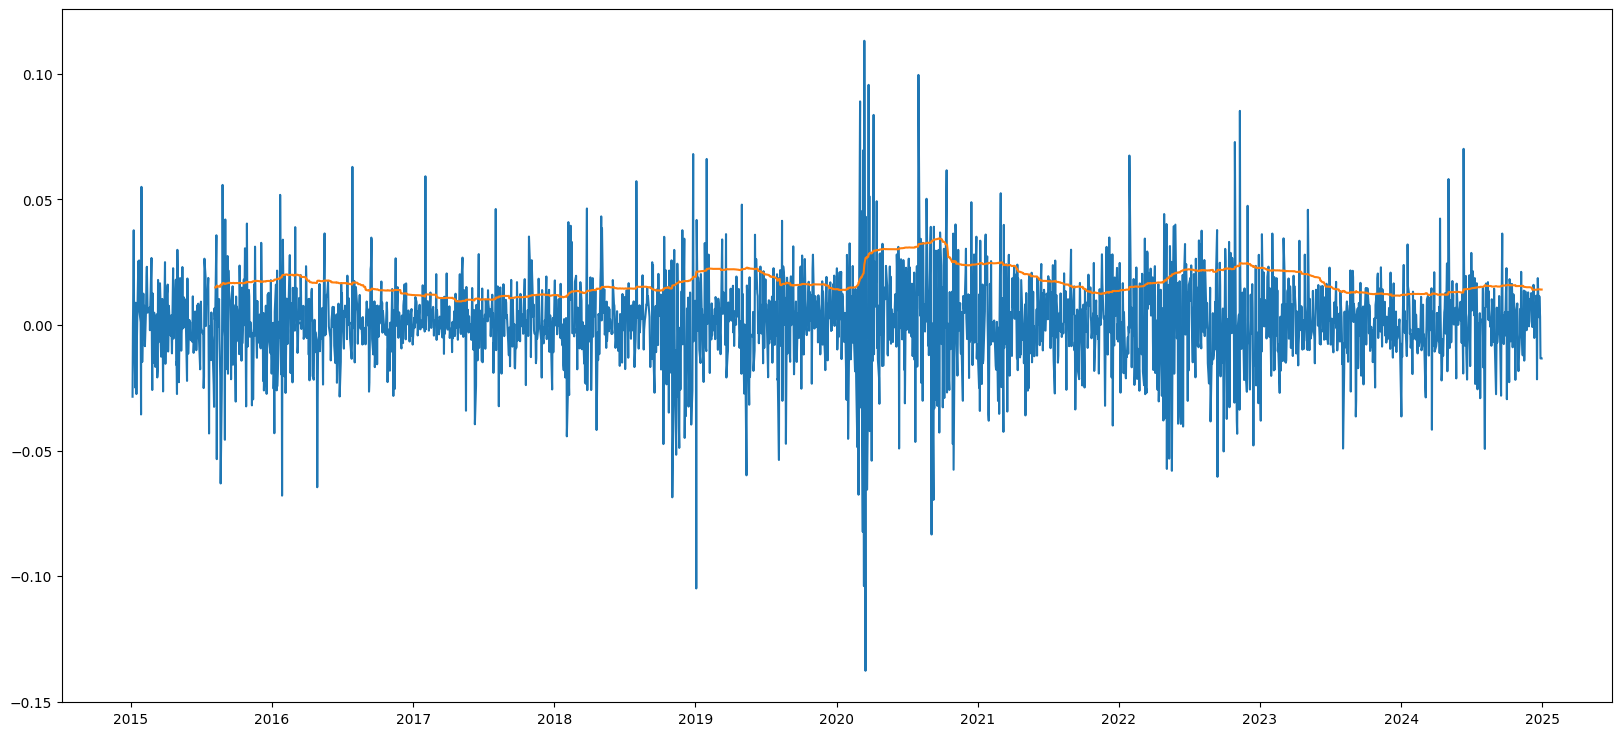

In [ ]:
plt.figure(figsize=(20,9))
plt.plot(data.index,data.returns)
plt.plot(data.index,data['std'])


# Yield curve

In [ ]:
X=[0.25, 0.5, 0.75, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]

Y=[2.566698,2.463905,2.381454,2.316180,2.178829,2.161176,2.200264,2.263250,2.333244,2.401814,2.464993,2.521156,2.569884,2.611368,2.646081,2.674616,2.697597,2.715629,2.729283,2.739081,2.745498,2.748960,2.749848,2.748502,2.745222,2.740275,2.733898,2.726298,2.717660,2.708146,2.697899,2.687045,2.675693]

In [ ]:
def nel_sie(T,b0,b1,b2,tau):
  d1=(1-np.exp(-T/tau))/(T/tau)
  d2=d1-np.exp(-T/tau)
  return(b0+b1*d1+b2*d2)

In [ ]:
"""L=curve_fit(nel_sie,X,Y,[1.216810,1.473766,-0.975379,1.547558])"""
L=curve_fit(nel_sie,X,Y,method='trf')

In [ ]:
estimate=[nel_sie(i,L[0][0],L[0][1],L[0][2],L[0][3]) for i in X]

In [ ]:
L

(array([ 2.88070332, -0.12098851, -2.23127929,  1.39445599]),
 array([[ 3.75978098e-04, -7.32372677e-04,  2.72502256e-05,
          1.49981803e-03],
        [-7.32372677e-04,  4.40001910e-03, -7.51528548e-03,
         -6.45690421e-03],
        [ 2.72502256e-05, -7.51528548e-03,  2.26484535e-02,
          1.09706289e-02],
        [ 1.49981803e-03, -6.45690421e-03,  1.09706289e-02,
          1.32800823e-02]]))

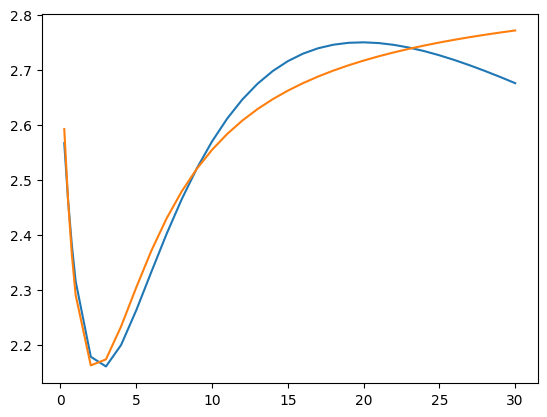

In [ ]:
plt.plot(X,Y)

plt.plot(X,estimate)

In [ ]:
T=np.array([0.5*i for i in range(33)])
rate_grid=np.array(np.interp(T,X,Y))
coupon=4

In [ ]:
fixed_leg=np.sum(np.exp(-rate_grid/100 * T))*coupon/200
fixed_leg

0.5422385364126063

In [ ]:
FRA=1/T[1:] *(np.exp(-rate_grid[:-1]/100*T[:-1])/np.exp(-rate_grid[1:]/100*T[1:])-1)
FRA

array([0.02479145, 0.01090127, 0.00707108, 0.00495641, 0.00429226,
       0.00354715, 0.00330177, 0.00293848, 0.00277687, 0.00256297,
       0.00242348, 0.00228064, 0.00215257, 0.00204849, 0.00193095,
       0.00185033, 0.00174361, 0.00167841, 0.00158234, 0.00152796,
       0.00144198, 0.00139558, 0.00131884, 0.00127858, 0.00121017,
       0.00117477, 0.00111379, 0.00108235, 0.00102795, 0.00099979,
       0.00095122, 0.00092583])

In [ ]:
floating_leg= np.sum(np.exp(-rate_grid[:1]/100*T[1:])*FRA/2)
floating_leg

0.04507445242253551

Text(0.5, 1.0, 'Vasicek Model Simulation')

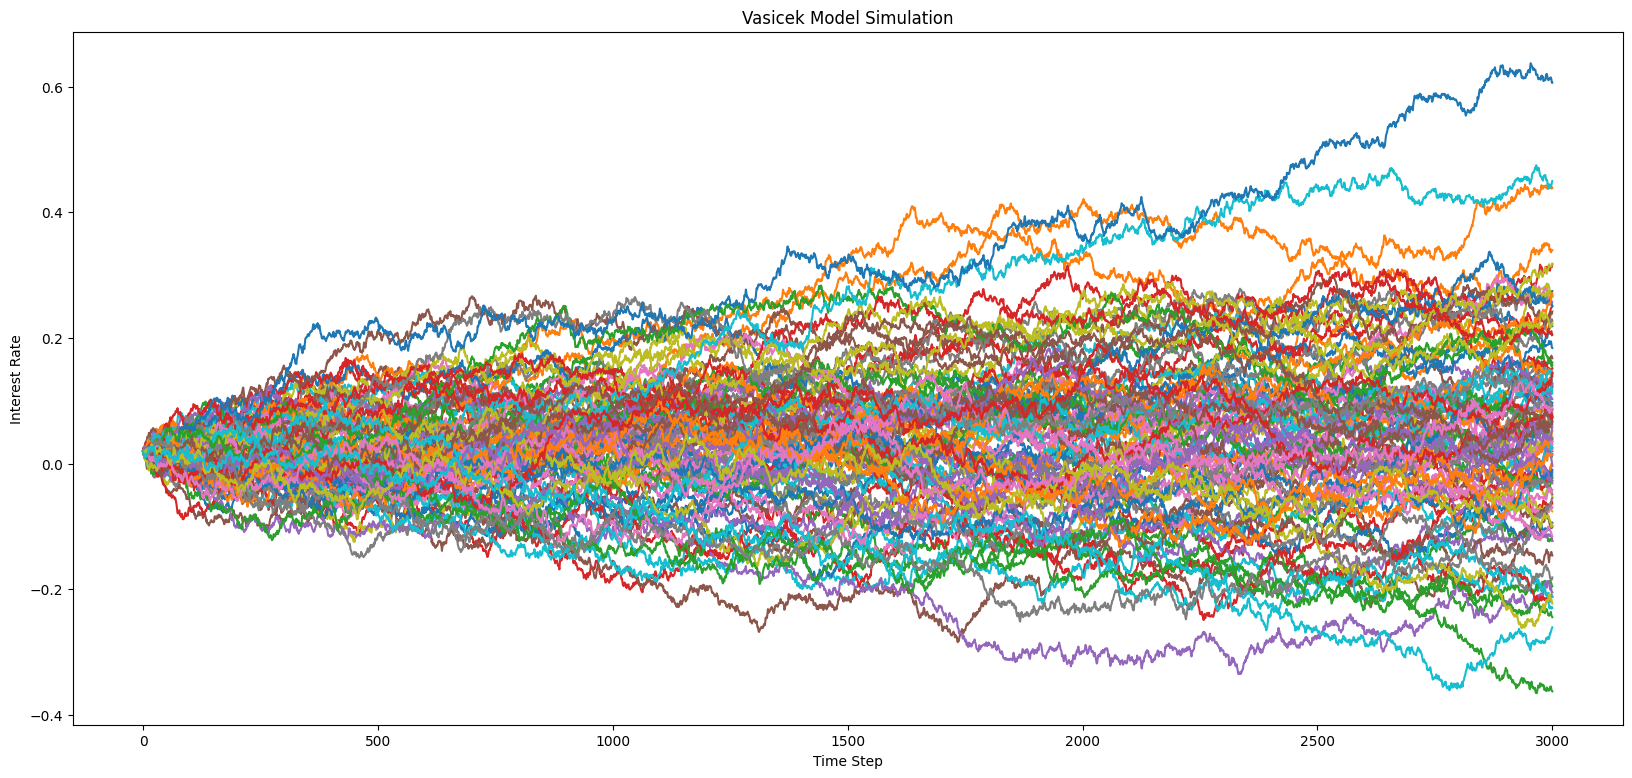

In [ ]:
def vasicek_model(r0, a, b, sigma, T, dt):
    """
    Simulates interest rates using the Vasicek model.

    Args:
        r0: Initial interest rate.
        a: Mean reversion speed.
        b: Long-term mean interest rate.
        sigma: Volatility of interest rates.
        T: Time horizon.
        dt: Time step.

    Returns:
        A NumPy array of simulated interest rates.
    """

    num_steps = int(T / dt)
    rates = np.zeros(num_steps + 1)
    rates[0] = r0

    for i in range(num_steps):
        dW = np.random.normal(0, np.sqrt(dt))  # Brownian motion increment
        rates[i+1] = rates[i] + a * (b - rates[i]) * dt + sigma * dW

    return rates


r0 = 0.02
a = 0.1
b = 0.03
sigma = 0.1
T = 3
dt = 1/(1000)

simulated_rates = vasicek_model(r0, a, b, sigma, T, dt)

plt.figure(figsize=(20,9))

for i in range(100):
  simulated_rates = vasicek_model(r0, a, b, sigma, T, dt)

  plt.plot(simulated_rates)
plt.xlabel('Time Step')
plt.ylabel("Interest Rate")
plt.title('Vasicek Model Simulation')


In [ ]:
def MC_vasicek(nb_simulations, r0, a, b, sigma, steps):
  Rates = np.zeros((nb_simulations, steps))
  Rates[:, 0] = r0
  dt = 1/steps
  for i in range(1, steps):
      dr = a * (b - Rates[:, i-1]) * dt + sigma * np.sqrt(dt) * np.random.normal(size=nb_simulations)
      Rates[:, i] = Rates[:, i-1] + dr
  return Rates

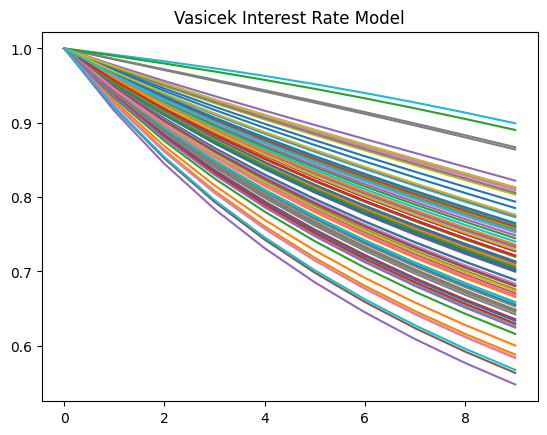

In [ ]:
nb_simulations = 100
steps = 1000
b = 0.05
a = 0.1
sigma = 0.02
freq = 0.5
r0 = 0.03
T = 10
t = 0
R = MC_vasicek(nb_simulations, r0, a, b, sigma, steps)
R_inf = b - sigma**2/(2*(a**2))

years = 10
zero_coupon = np.zeros((nb_simulations, years))
for i in range(years):
  zero_coupon[:, i] = np.exp(- R_inf * (i) + (R_inf - R[:,-1]) * ((1 - np.exp(-a * (i)))/a) - sigma**2/ (4 * a**3) * (1 - np.exp(-a * (i))**2))

for j in range(nb_simulations):
  plt.plot(zero_coupon[j,:])
plt.title('Vasicek Interest Rate Model')
plt.show()

In [ ]:
# prompt: price the zero coupon bond with vasicek

def zero_coupon_bond_price_vasicek(r0, a, b, sigma, T, t):


    B = (1 - np.exp(-a * (T - t))) / a
    A = np.exp((B - (T - t)) * (a * b - 0.5 * sigma ** 2) / a - (sigma ** 2 * B ** 2) / (4 * a))
    return A * np.exp(-B * r0)


r0 = 0.02
a = 0.01
b = 0.01
sigma = 0.02
T =2.5
t = 2

bond_price = zero_coupon_bond_price_vasicek(r0, a, b, sigma, T, t)
print(f"The price of the zero-coupon bond is: {bond_price}")


The price of the zero-coupon bond is: 0.7850207981925981


# Swaption

In [ ]:

import numpy as np
from scipy.stats import norm

def swaption_price(S, K, vol, T, r, is_payer):


    d1 = (np.log(S / K) + 0.5 * vol ** 2 * T) / (vol * np.sqrt(T))
    d2 = d1 - vol * np.sqrt(T)

    if is_payer:
        price = np.exp(-r * T) * (S * norm.cdf(d1) - K * norm.cdf(d2))
    else:
        price = np.exp(-r * T) * (K * norm.cdf(-d2) - S * norm.cdf(-d1))

    return price


S = 0.05
K = 0.04
vol = 0.2
T = 1
r = 0.03
is_payer = True

price = swaption_price(S, K, vol, T, r, is_payer)
print(f"The price of the swaption is: {price}")


# $$S_{α,β}(t)=\frac{P(t,T_α)-P(t,T_β)}{∑\limits _{i=α+1}^βτP(t,T_i)}$$